In [12]:
import asyncio
import time

ik_timestamps = []


async def ik_loop():
    period = 0.01  # 100 Hz
    next_time = time.perf_counter()

    while True:
        ik_timestamps.append(time.perf_counter())

        next_time += period
        await asyncio.sleep(
            max(0, next_time - time.perf_counter())
        )


async def vlm_loop():
    while True:
        start = time.perf_counter()
        print(f"VLM started at {start:.3f}")

        await asyncio.sleep(0.5)

        end = time.perf_counter()
        print(f"VLM ended at {end:.3f}")


async def main():
    print("Starting benchmark...\n")

    ik_task = asyncio.create_task(ik_loop())
    vlm_task = asyncio.create_task(vlm_loop())

    await asyncio.sleep(10)

    ik_task.cancel()
    vlm_task.cancel()

    periods = [
        ik_timestamps[i] - ik_timestamps[i - 1]
        for i in range(1, len(ik_timestamps))
    ]

    frequencies = [1 / p for p in periods]

    print("\nBenchmark Complete")
    print(f"Collected {len(ik_timestamps)} timestamps")
    print(f"Average Frequency: {sum(frequencies)/len(frequencies):.2f} Hz")
    print(f"Largest Gap: {max(periods)*1000:.2f} ms")


await main()

Starting benchmark...

VLM started at 4290.633
VLM ended at 4291.134
VLM started at 4291.134
VLM ended at 4291.635
VLM started at 4291.635
VLM ended at 4292.136
VLM started at 4292.136
VLM ended at 4292.637
VLM started at 4292.637
VLM ended at 4293.138
VLM started at 4293.138
VLM ended at 4293.639
VLM started at 4293.640
VLM ended at 4294.140
VLM started at 4294.140
VLM ended at 4294.640
VLM started at 4294.641
VLM ended at 4295.141
VLM started at 4295.141
VLM ended at 4295.642
VLM started at 4295.643
VLM ended at 4296.144
VLM started at 4296.144
VLM ended at 4296.645
VLM started at 4296.645
VLM ended at 4297.146
VLM started at 4297.146
VLM ended at 4297.647
VLM started at 4297.647
VLM ended at 4298.148
VLM started at 4298.148
VLM ended at 4298.649
VLM started at 4298.649
VLM ended at 4299.150
VLM started at 4299.150
VLM ended at 4299.650
VLM started at 4299.650
VLM ended at 4300.151
VLM started at 4300.151

Benchmark Complete
Collected 1000 timestamps
Average Frequency: 100.53 Hz
Larg

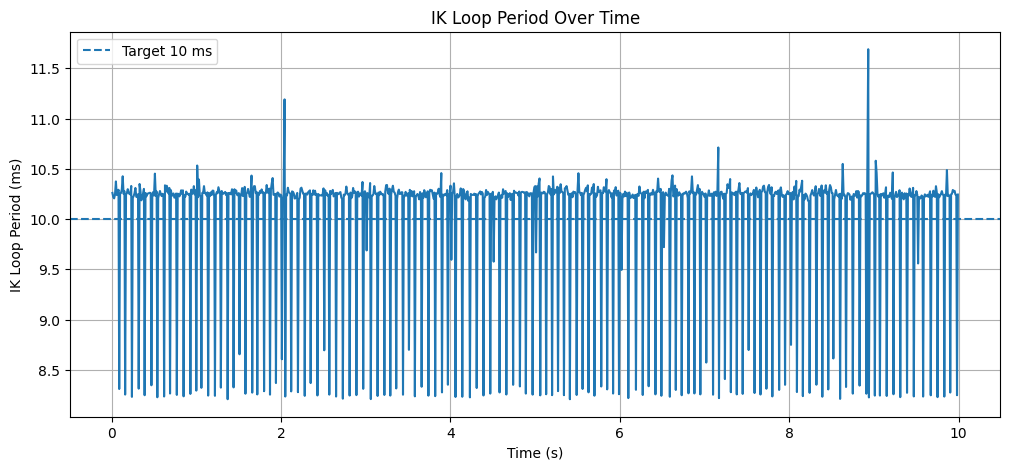

In [14]:
import matplotlib.pyplot as plt

periods_ms = [
    (ik_timestamps[i] - ik_timestamps[i - 1]) * 1000
    for i in range(1, len(ik_timestamps))
]

time_axis = [
    ik_timestamps[i] - ik_timestamps[0]
    for i in range(1, len(ik_timestamps))
]

plt.figure(figsize=(12, 5))

plt.plot(time_axis, periods_ms)

plt.axhline(
    y=10,
    linestyle="--",
    label="Target 10 ms"
)

plt.xlabel("Time (s)")
plt.ylabel("IK Loop Period (ms)")
plt.title("IK Loop Period Over Time")

plt.legend()
plt.grid(True)

plt.show()

#**Written Analysis**

##**Objective**
The objective of this benchmark was to evaluate whether a high-frequency Inverse Kinematics (IK) control loop running at 100 Hz can maintain its timing performance while a slower Vision-Language Model (VLM) inference task is executing concurrently. The experiment was designed to validate asynchronous task decoupling using Python's asyncio framework.

##**Methodology**
Two asynchronous tasks were created:
1. An IK loop running at a target frequency of 100 Hz (10 ms period).
2. A simulated VLM inference task with a duration of 500 ms per inference.

Both tasks were scheduled concurrently using asyncio.create_task(). The IK loop recorded a timestamp on every iteration, allowing precise measurement of actual execution timing throughout the benchmark.

To maintain accurate loop timing, the IK loop used deadline scheduling (next_time += period) rather than repeatedly sleeping for a fixed duration. This approach minimizes timing drift and better represents how real robotic control loops are implemented.

The benchmark was executed for 10 seconds, resulting in approximately 1000 IK loop iterations.

##**Performance Metrics**
The recorded timestamps were used to calculate:
- IK loop period (time between consecutive iterations)
- IK loop frequency
- Average operating frequency
- Largest observed timing gap

The benchmark produced the following results:
- 1000 timestamps collected
- 999 measured periods
- Average frequency: approximately 100.56 Hz
- Largest observed period: approximately 11.90 ms
- Graph Interpretation

The graph plots the IK loop period over time. The dashed horizontal line represents the ideal target period of 10 ms, corresponding to the desired 100 Hz control frequency.

The measured periods remain tightly clustered around the 10 ms target for the entire duration of the benchmark. Small fluctuations are visible, with most measurements lying between approximately 8.2 ms and 10.3 ms. Occasional peaks reaching approximately 11.9 ms are also present.

These variations are expected and are primarily caused by operating system scheduling, Python interpreter overhead, and normal event-loop jitter. Such fluctuations are common in non-real-time operating systems and do not indicate a failure of the asynchronous design.

Most importantly, the graph does not contain any large latency spikes or prolonged pauses. If the VLM task had blocked the event loop, the graph would have shown significant jumps in loop period, potentially hundreds of milliseconds long. No such behavior was observed.

##**Verification of Async Decoupling**
The purpose of asynchronous decoupling is to ensure that a slow perception task does not interfere with a fast control task. In this benchmark, the VLM task repeatedly performed simulated 500 ms inference operations while the IK loop continued executing near its target period.

The collected measurements show that the IK loop maintained an average frequency slightly above 100 Hz and never experienced large timing interruptions. The maximum observed deviation from the target period was small, indicating that the event loop continued scheduling the control task even while VLM inference was active.

These results demonstrate that the asynchronous architecture successfully isolates the high-frequency control loop from the slower VLM workload.

##**Conclusion**
The benchmark successfully validated the asynchronous design. The IK loop maintained stable operation at approximately 100 Hz throughout the experiment, despite the concurrent execution of a simulated VLM inference task. Only minor timing jitter was observed, and no evidence of blocking or control-loop starvation was detected.

The results indicate that the current asyncio-based approach provides effective decoupling between control and perception workloads, making it suitable for robotic systems where fast control loops must remain responsive while computationally expensive perception tasks run in parallel.